# Purpose of the notebook
Here we're going to cover the data analysis of the [dblp](https://dblp.uni-trier.de/) dataset. We're going to cover:
- Show the heads of the sql tables we're working with
- Find out most active authors overall and by year
- Plot some values like:
    + number of works published each yea
    + average number of people working on papers
    + distribution of publication types
    + etc.
- Show trends in the topics covered in papers over time
- Visualize collaboration graphs of authors
- Use those collaboration graphs for a paper recommendation system


Resolving of the synonyms like:
- John Smith
- J. Smith
- etc.

has been done during creation of the database, missing values for authors has been resolved, the data we're going to be working with while not perfect is already relatively clean.

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import logging
from pathlib import Path
import numpy as np
import re
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

In [7]:
import sys
import os

sys.path.append(os.path.abspath('..')) # for relative imports

In [8]:
from src.trend_analysis.trend_analysis import compute_title_ngram_trends, plot_top
from src.graph.collaboration_graph import recommend_papers_from_paper, build_collaboration_graph, plot_collaboration_graph

In [9]:
pd.set_option("display.max_rows", 500)

In [10]:
XML_GZ_PATH  = "../data/raw/dblp.xml.gz"
DB_PATH = "../data/db/dblp.duckdb"
LOG_PATH   = "../logs/eda.log"
TMP_PATH   = "/tmp/duckdb_tmp"
PLOT_PATH  = "../plots"

In [11]:
logging.basicConfig(level=logging.INFO, filename=LOG_PATH, filemode="w",
                    format="%(asctime)s - %(levelname)s - %(message)s")

In [12]:
Path(TMP_PATH).mkdir(parents=True,exist_ok=True)

In [13]:
conn = duckdb.connect(DB_PATH)

Since the dataset is large we need to set some limits and make the duckdb spill to the disk. This will make some querries requiring large intermediate tables significantly slower, but they will not overflow the RAM at least.

In [14]:
conn.execute("SET memory_limit = '4GB'")
conn.execute(f"SET temp_directory = '{TMP_PATH}'")
conn.execute("SET threads = 1")
conn.execute("SET preserve_insertion_order = false")

## Brief showcase of the heads of the tables.

In [15]:
conn.execute("SHOW tables").fetch_df()

,name
0,author_aliases
1,author_aliases_staging
2,person
3,work
4,work_contributor
5,work_relation


In [16]:
conn.execute("SELECT * FROM author_aliases LIMIT 5").fetch_df()

,alias_name,canonical_name
0,Mervat A. Madi,Mervat Madi
1,Dorothy Waugh,Dorothy Waugh
2,Yun-Jie Jhang,Yun-Jie Jhang
3,Cong-Binh Nguyen,Cong-Binh Nguyen
4,Hong-Nhat Quoc Hoang,Hong-Nhat Quoc Hoang


In [17]:
conn.execute("SELECT * FROM person LIMIT 5").fetch_df()

,person_id,canonical_name
0,1,(David) Jing Dai
1,2,(Max) Zong-Ming Cheng
2,3,(Sophy) Shu-Jiun Chen
3,4,(Zhou) Bryan Bai
4,5,(jim) Xiuquan Ji


In [18]:
conn.execute("SELECT * FROM work LIMIT 5").fetch_df()

,work_id,dblp_key,record_type,title,year,mdate,volume,number,pages,journal,booktitle,publisher,school,series,crossref,publtype,url,ee,isbn
0,1,ms/Hoffmann2008,mastersthesis,Regelbasierte Extraktion und asymmetrische Fus...,2009,2020-03-12,None,None,None,None,None,None,University of Trier,None,None,None,None,http://dblp.uni-trier.de/papers/DiplomarbeitOl...,None
1,2,ms/Ley2006,mastersthesis,Der Einfluss kleiner naturnaher Retentionsmaßn...,2006,2020-03-12,None,None,None,None,None,None,"Diplomarbeit, Universität Trier, FB VI, Physis...",None,None,None,None,http://dblp.uni-trier.de/papers/DiplomarbeitRi...,None
2,3,ms/Brown92,mastersthesis,PRPL: A Database Workload Specification Langua...,1992,2018-06-13,None,None,None,None,None,None,University of Wisconsin-Madison,None,None,None,None,None,None
3,4,ms/Vollmer2006,mastersthesis,Portierung des DBLP-Systems auf ein relational...,2006,2018-06-13,None,None,None,None,None,None,"Diplomarbeit, Universität Trier, FB IV, Inform...",None,None,None,None,http://dbis.uni-trier.de/Diplomanden/Vollmer/v...,None
4,5,ms/Klaas2007,mastersthesis,Who's Who in the World Wide Web: Approaches to...,2007,2020-03-12,None,None,None,None,None,None,"Diplomarbeit, LMU München, Informatik",None,None,None,None,http://www.pms.ifi.lmu.de/publikationen/diplom...,None


In [19]:
conn.execute("SELECT * FROM work_contributor LIMIT 5").fetch_df()

,work_id,person_id,role,position
0,49228,2767429,author,1
1,49228,282467,author,2
2,49229,884363,author,1
3,49230,2699578,author,1
4,49231,3720573,author,1


In [20]:
conn.execute("SELECT * FROM work_relation LIMIT 5").fetch_df()

,child_work_id,parent_work_id,relation_type
0,246347,245773,crossref
1,246342,245814,crossref
2,246322,245836,crossref
3,246341,245870,crossref
4,246331,246008,crossref


In [21]:
pd.DataFrame(conn.execute("SELECT * FROM work WHERE (work_id = 7 OR work_id = 158)").fetchall())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,7,series/ifip/computerization1985,book,"Computerization and Work, A Reader on Social A...",1985,2017-05-16,None,None,None,None,Computerization and Work,Springer,None,IFIP State-of-the-Art Reports,None,None,db/series/ifip/computerization1985.html,https://doi.org/10.1007/978-3-642-70453-6,978-3-540-15367-2
1,158,series/ifip/Briefs85,incollection,The Impact of Information Processing on the Wo...,1985,2017-05-16,None,None,34-50,None,Computerization and Work,None,None,None,series/ifip/computerization1985,None,db/series/ifip/computerization1985.html#Briefs85,https://doi.org/10.1007/978-3-642-70453-6_4,None


## Start of EDA

People appearing in the dataset in the highest total number of works:

In [22]:
conn.execute("SELECT p.canonical_name, COUNT(DISTINCT wp.work_id) as appearances FROM person p " \
             "JOIN work_contributor wp ON " \
             "p.person_id = wp.person_id " \
             "GROUP BY p.canonical_name " \
             "ORDER BY appearances DESC " \
             "LIMIT 10;").fetch_df()

,canonical_name,appearances
0,H. Vincent Poor,3285
1,Dusit Niyato,2633
2,Philip S. Yu,2608
3,Zhu Han 0001,2483
4,Yang Liu,2441
5,Dacheng Tao,2399
6,Wei Wang,2381
7,Mohamed-Slim Alouini,2297
8,Witold Pedrycz,2075
9,Wei Zhang,2041


Most active authors per year  

In [23]:
conn.execute("WITH author_per_year AS (SELECT p.canonical_name, w.year, COUNT(DISTINCT wc.work_id) AS appearances FROM " \
             "person p " \
             "JOIN work_contributor wc ON " \
             "p.person_id = wc.person_id " \
             "JOIN work w ON wc.work_id = w.work_id " \
             "GROUP BY p.canonical_name, w.year) " \
             "SELECT * FROM ( " \
             "SELECT *, ROW_NUMBER() OVER (PARTITION BY year ORDER BY appearances DESC) AS rn " \
             "FROM author_per_year) WHERE rn = 1 ORDER BY year DESC;").fetch_df()

,canonical_name,year,appearances,rn
0,Dusit Niyato,2026,252,1
1,Dusit Niyato,2025,572,1
2,Dusit Niyato,2024,469,1
3,Dacheng Tao,2023,281,1
4,Dacheng Tao,2022,248,1
5,H. Vincent Poor,2021,254,1
6,H. Vincent Poor,2020,261,1
7,Mohsen Guizani,2019,189,1
8,H. Vincent Poor,2018,165,1
9,Mohamed-Slim Alouini,2017,155,1


We see quite a few repeating names if someone is very actively publishing they're unlikely to be active over just 1 year.

Number of works published over time:

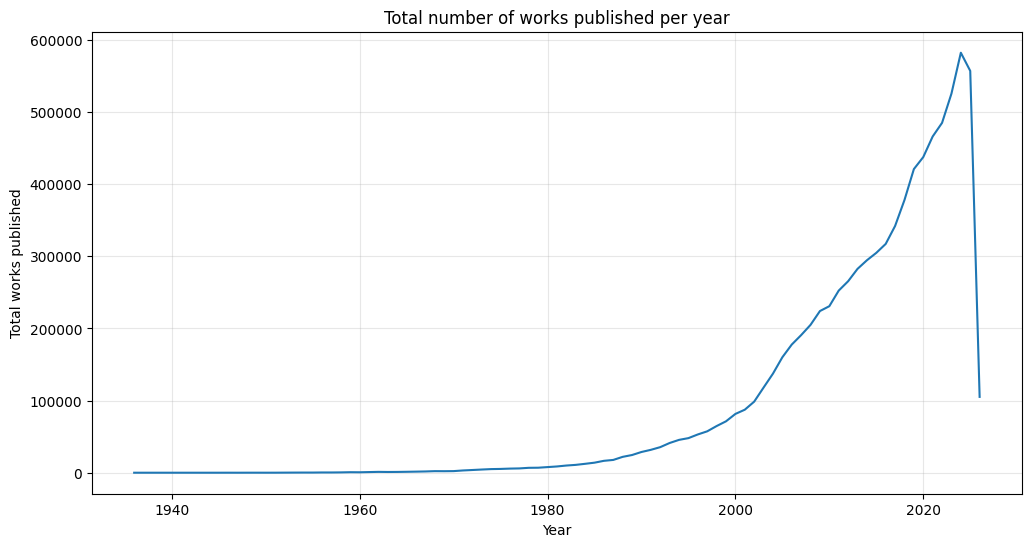

In [24]:
total_works_trend = conn.execute("SELECT w.year, COUNT(DISTINCT w.work_id) as total_works FROM work w " \
             "GROUP BY w.year ORDER BY year;").fetch_df()

plt.figure(figsize=(12, 6))
plt.plot(total_works_trend["year"], total_works_trend["total_works"])
plt.xlabel("Year")
plt.ylabel("Total works published")
plt.title("Total number of works published per year")
plt.grid(True, alpha=0.3)

We can see that the number of works published increases significantly over time (excluding the 2026 data which is not complete since the year hasn't ended yet). It's important to remember this is only data recorded in the DBLP dataset.

Average number of people working on a single paper

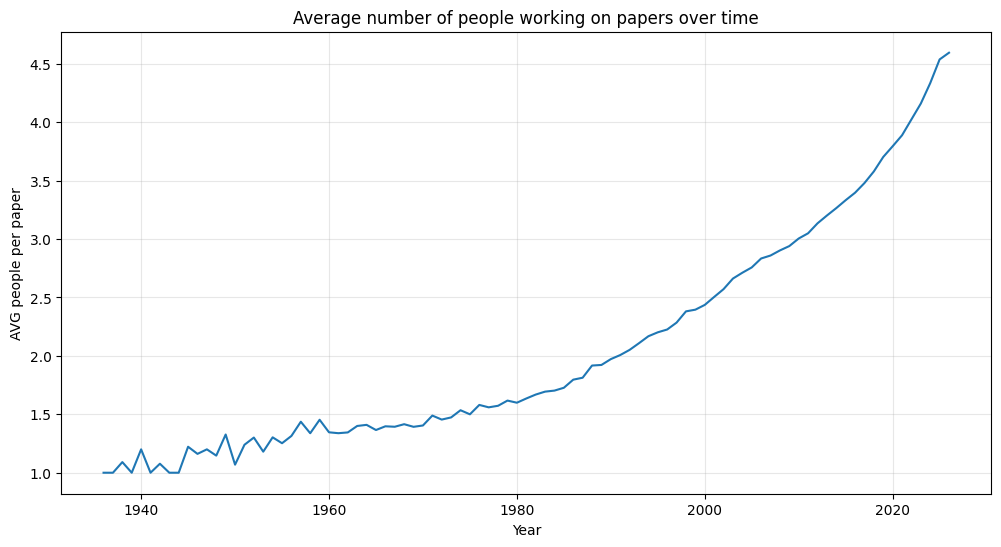

In [25]:
avg_people_per_paper = conn.execute("""WITH authors_per_work AS (
    SELECT
        w.work_id,
        w.year,
        COUNT(DISTINCT wc.person_id) AS authors
    FROM work w
    JOIN work_contributor wc ON wc.work_id = w.work_id
    WHERE w.year IS NOT NULL
    GROUP BY w.work_id, w.year
)
SELECT
    year,
    AVG(authors) AS avg_authors_per_work
FROM authors_per_work
GROUP BY year
ORDER BY year;""").fetch_df()

plt.figure(figsize=(12, 6))
plt.plot(avg_people_per_paper["year"], avg_people_per_paper["avg_authors_per_work"])
plt.xlabel("Year")
plt.ylabel("AVG people per paper")
plt.title("Average number of people working on papers over time")
plt.grid(True, alpha=0.3)

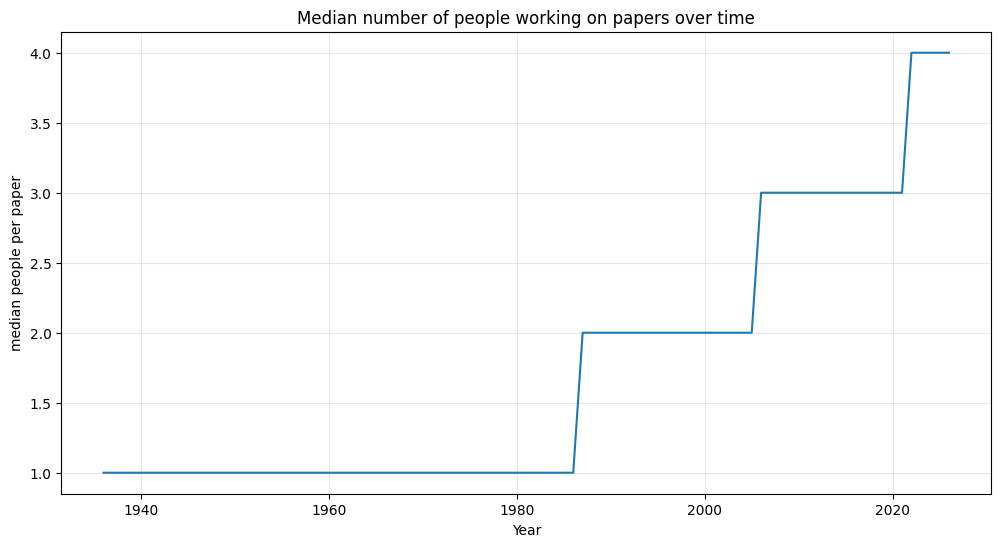

In [26]:
median_people_per_paper = conn.execute("""WITH authors_per_work AS (
    SELECT
        w.work_id,
        w.year,
        COUNT(DISTINCT wc.person_id) AS authors
    FROM work w
    JOIN work_contributor wc ON wc.work_id = w.work_id
    WHERE w.year IS NOT NULL
    GROUP BY w.work_id, w.year
)
SELECT
    year,
    MEDIAN(authors) AS median_authors_per_work
FROM authors_per_work
GROUP BY year
ORDER BY year;""").fetch_df()

plt.figure(figsize=(12, 6))
plt.plot(median_people_per_paper["year"], median_people_per_paper["median_authors_per_work"])
plt.xlabel("Year")
plt.ylabel("median people per paper")
plt.title("Median number of people working on papers over time")
plt.grid(True, alpha=0.3)

The team sizes seem to be growing over time this might be due to:
- higher total number of scientists so projects which in the past would have to be handled by a single scientist can now be split more efficiently
- higher complexity of topics covered, requiring bigger teams 

Grouping how many authors participated in how many papers

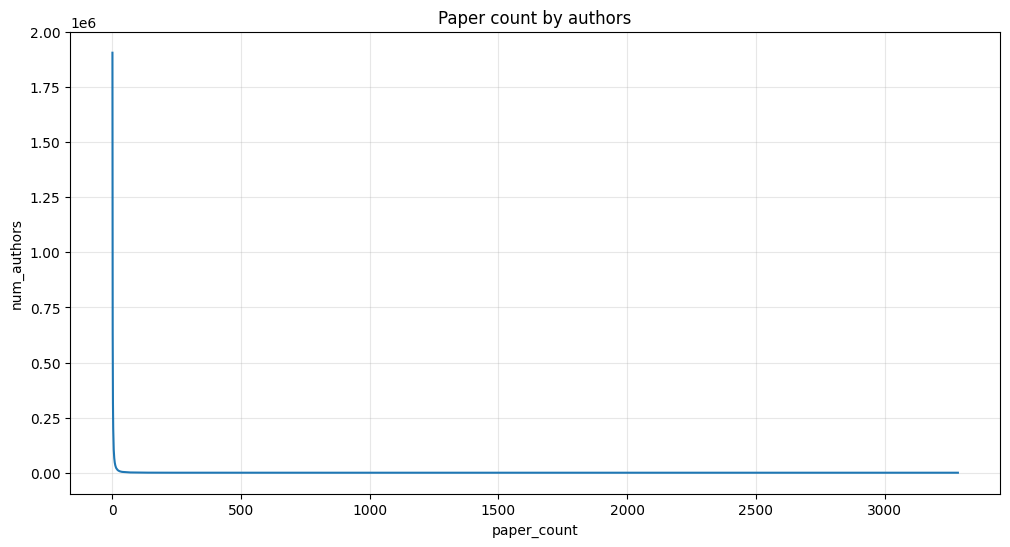

In [27]:
authors_by_papercount = conn.execute("""
WITH author_papers AS (
    SELECT
        p.person_id,
        COUNT(DISTINCT wc.work_id) AS paper_count
    FROM person p
    JOIN work_contributor wc ON p.person_id = wc.person_id
    GROUP BY p.person_id
)
SELECT
    paper_count,
    COUNT(*) AS num_authors
FROM author_papers
GROUP BY paper_count
ORDER BY paper_count;
""").fetch_df()

plt.figure(figsize=(12, 6))
plt.plot(authors_by_papercount["paper_count"], authors_by_papercount["num_authors"])
plt.xlabel("paper_count")
plt.ylabel("num_authors")
plt.title("Paper count by authors")
plt.grid(True, alpha=0.3)

There's a lot of scientists with few papers and very few authors with a lot of papers

Excluding the authors with less then n papers:

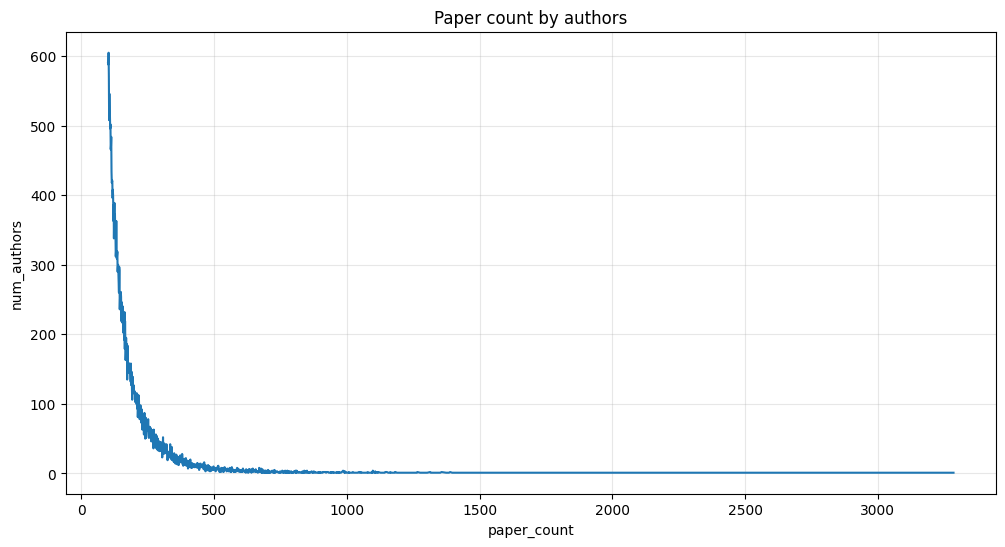

In [28]:
n = 100


plt.figure(figsize=(12, 6))
plt.plot(authors_by_papercount["paper_count"][authors_by_papercount["paper_count"] > n], authors_by_papercount["num_authors"][authors_by_papercount["paper_count"] > n])
plt.xlabel("paper_count")
plt.ylabel("num_authors")
plt.title("Paper count by authors")
plt.grid(True, alpha=0.3)

Even if we exclude authors with the smallest number of papers the number of authors still very strongly diminishes when increasing the number of papers.

Publication type mix over time:

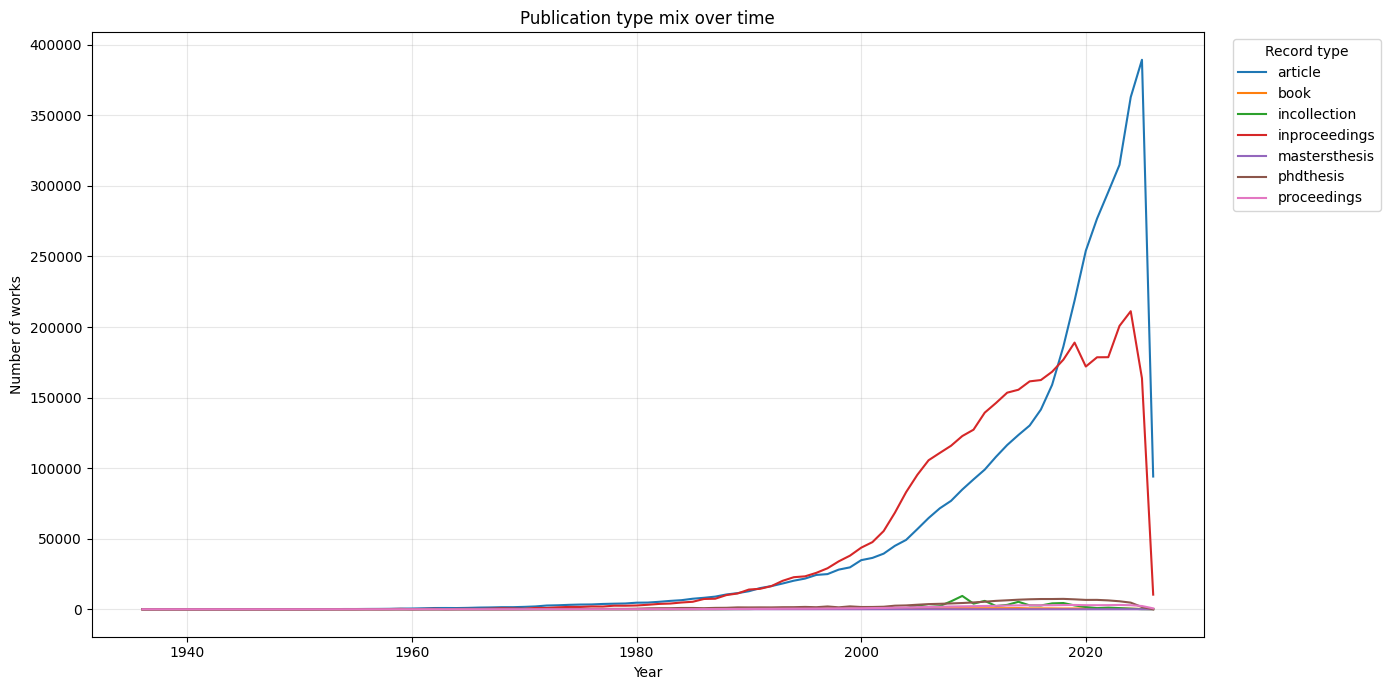

In [29]:
publication_mix = conn.execute("""
    SELECT
        w.year,
        w.record_type,
        COUNT(*) AS total_works
    FROM work w
    WHERE w.year IS NOT NULL
    GROUP BY w.year, w.record_type
    ORDER BY w.year, total_works DESC, w.record_type;
""").fetch_df()

pivot = publication_mix.pivot(index="year", columns="record_type", values="total_works").fillna(0)

plt.figure(figsize=(14, 7))

for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)

plt.xlabel("Year")
plt.ylabel("Number of works")
plt.title("Publication type mix over time")
plt.legend(title="Record type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Articles and inproceedings are dominating the publication landscape and they're lead seems to only be growing over time. Since 1 scientist writes only a single masterthesis and maybe 1 phdthesis the relative increase in the volume of articles and inproceedings might mean that an average scientist becomes more productive, but this might also be a limitation of the dblp dataset having much more recent publications.

Most popular venues:

In [30]:
conn.execute("""
    WITH venue_base AS (
        SELECT
            COALESCE(
                NULLIF(TRIM(journal), ''),
                NULLIF(TRIM(booktitle), ''),
                NULLIF(TRIM(publisher), ''),
                NULLIF(TRIM(school), ''),
                NULLIF(TRIM(series), '')
            ) AS venue_name
        FROM work
    )
    SELECT
        venue_name,
        COUNT(*) AS total_works
    FROM venue_base
    WHERE venue_name IS NOT NULL
    GROUP BY venue_name
    ORDER BY total_works DESC
    LIMIT 50;
""").fetch_df()


,venue_name,total_works
0,CoRR,878682
1,IEEE Access,105749
2,Sensors,64440
3,ICASSP,47722
4,Remote. Sens.,36114
5,IGARSS,33702
6,ICRA,30221
7,Expert Syst. Appl.,28041
8,AAAI,27110
9,IROS,26355


## Trends in topics covered
In this section we're going to check the trends in the paper topics.
This is achieved by scanning the most commonly appearing words and phrases in the titles over time, after removing commonly appearing non-informative words.


In [31]:
title_data = conn.execute("""
    SELECT
        year,
        title
    FROM work
    WHERE year IS NOT NULL
      AND year >= 1950
      AND title IS NOT NULL
      AND TRIM(title) <> ''
    ORDER BY year;
""").fetch_df()

In [33]:
DOMAIN_STOPWORDS = {
    "paper", "papers", "study", "case", "approach", "method", "methods", "based",
    "using", "use", "towards", "toward", "new", "problem", "problems", "via"
}

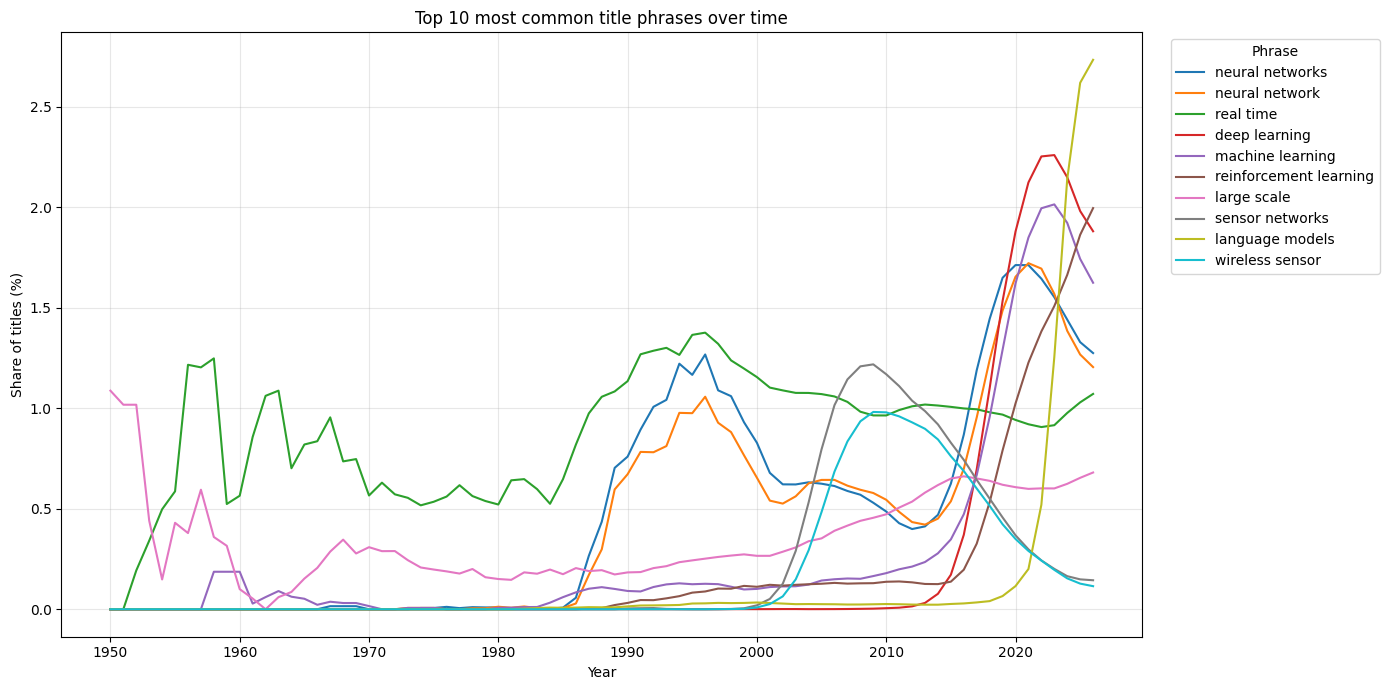

In [44]:
yearly_share, totals = compute_title_ngram_trends(
    title_data,
    ngram_range=(2, 2),
    min_df=100,
    max_features=1000,
    sample_size=200000,
    smooth_window=3,
    extra_stopwords=DOMAIN_STOPWORDS
)

plot_top(yearly_share, totals, top_n=10)

One interesting thing we can observe are the two jumps for neural network based architecture, one in mid 90s and one very recently after 2020. We can also see how machine learning, deep learning and (large) language models are currently dominating the research.

## Collaboration graph

In this section we focus on building collaboration graphs - given `author` and `max_hops` we're generating a local graph around this author.
- people with distance 1 worked with passed `author` on a paper
- people with distance 2 worked on a paper with someone that the passed `author` worked with
- etc.

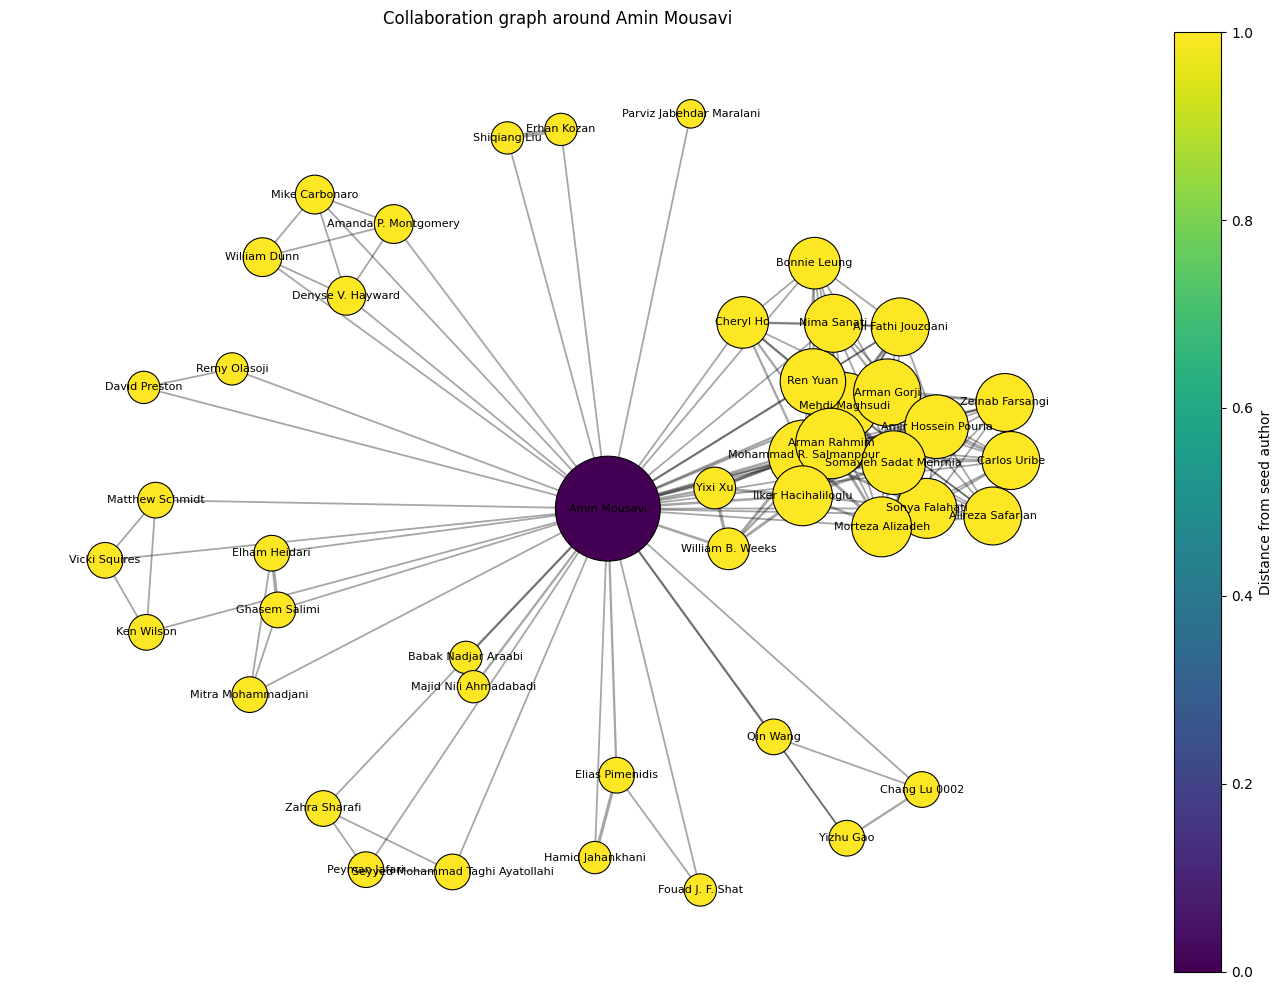

In [48]:
G = build_collaboration_graph(
    conn,
    author_name="Amin Mousavi",
    max_hops=1,
    max_nodes=100,
)

plot_collaboration_graph(
    G,
    center_author="Amin Mousavi",
    show_labels=True,
    label_distance=1,
)

- color - distance
- size - degree of the node
- line thickness - weight of the connection - number of papers collaborated on 

For exanple here we can see some groups emerge that `Amin Mousavi` was a part of with 1 particularly large group. If we were trying to figure out who the passed author worked with it might be a good idea to check people from this large group and the papers they worked on.

Scientific paper recommendation system, it's based on the collaboration graphs which were presented above.
>Given this paper, what other papers are written by authors who are close to the paper's author network? 

How it works:
- you first pass the initial paper
- collaboration graph is made based on the authors of the original paper and the hop amount
- we collect papers built by those nearby authors
- papers are more likely to be recommended if:
    - it's written by authors closer to the seed authors
    - it's written by multiple authors
    

In [60]:
conn.execute("""
      SELECT * FROM
      work w JOIN work_contributor wc ON
      w.work_id = wc.work_id
      JOIN person p ON p.person_id = wc.person_id
      WHERE p.canonical_name = 'Amin Mousavi'
      LIMIT 10;
             """).fetch_df()

,work_id,dblp_key,record_type,title,year,mdate,volume,number,pages,journal,...,publtype,url,ee,isbn,work_id_2,person_id,role,position,person_id_2,canonical_name
0,103956,conf/edemocracy/ShatMP13,inproceedings,Electronic Government Enactment in a Small Dev...,2013,2017-05-25,None,None,83-92,None,...,None,db/conf/edemocracy/edemocracy2013.html#ShatMP13,https://doi.org/10.1007/978-3-319-11710-2_8,None,103956,183673,author,2,183673,Amin Mousavi
1,2210183,conf/aaai/MousaviAA15,inproceedings,Context Transfer and Q-Transferable Tasks.,2015,2023-09-04,None,None,None,None,...,None,db/conf/aaai/robot2015.html#MousaviAA15,http://aaai.org/ocs/index.php/WS/AAAIW15/paper...,None,2210183,183673,author,1,183673,Amin Mousavi
2,2573771,conf/fedcsis/OlasojiPM14,inproceedings,Requirement Engineering for Effective Mobile L...,2014,2023-08-07,None,None,851-860,None,...,None,db/conf/fedcsis/fedcsis2014.html#OlasojiPM14,https://doi.org/10.15439/2014F98,None,2573771,183673,author,3,183673,Amin Mousavi
3,2764474,conf/miccai/SalmanpourMXWH24,inproceedings,Do High-Performance Image-to-Image Translation...,2024,2025-03-03,None,None,24-34,None,...,None,db/conf/miccai/asmus2024.html#SalmanpourMXWH24,https://doi.org/10.1007/978-3-031-73647-6_3,None,2764474,183673,author,2,183673,Amin Mousavi
4,4511930,journals/cars/SalmanpourMXWH26,article,Influence of high-performance image-to-image t...,2026,2026-03-09,21,1,125-135,Int. J. Comput. Assist. Radiol. Surg.,...,None,db/journals/cars/cars21.html#SalmanpourMXWH26,https://doi.org/10.1007/s11548-025-03481-3,None,4511930,183673,author,2,183673,Amin Mousavi
5,4609336,journals/bjet/MontgomeryMCHD19,article,Using learning analytics to explore self-regul...,2019,2020-07-14,50,1,114-127,Br. J. Educ. Technol.,...,None,db/journals/bjet/bjet50.html#MontgomeryMCHD19,https://doi.org/10.1111/bjet.12590,None,4609336,183673,author,2,183673,Amin Mousavi
6,4610688,journals/bjet/WangM23,article,Which log variables significantly predict acad...,2023,2025-12-07,54,1,142-191,Br. J. Educ. Technol.,...,None,db/journals/bjet/bjet54.html#WangM23,https://doi.org/10.1111/bjet.13282,None,4610688,183673,author,2,183673,Amin Mousavi
7,5095043,journals/isci/MousaviJ02,article,Double-faced rough sets and rough communication.,2002,2021-04-22,148,1-4,41-53,Inf. Sci.,...,None,db/journals/isci/isci148.html#MousaviJ02,https://doi.org/10.1016/S0020-0255(02)00275-X,None,5095043,183673,author,1,183673,Amin Mousavi
8,5461310,journals/aiedu/MousaviSSW21,article,Assessing the Effectiveness of Student Advice ...,2021,2021-09-20,31,3,603-621,Int. J. Artif. Intell. Educ.,...,None,db/journals/aiedu/aiedu31.html#MousaviSSW21,https://doi.org/10.1007/s40593-020-00210-6,None,5461310,183673,author,1,183673,Amin Mousavi
9,5807013,journals/cin/MousaviAA14,article,Context Transfer in Reinforcement Learning Usi...,2014,2020-10-26,2014,None,428567:1-428567:10,Comput. Intell. Neurosci.,...,None,db/journals/cin/cin2014.html#MousaviAA14,https://doi.org/10.1155/2014/428567,None,5807013,183673,author,1,183673,Amin Mousavi


In [58]:
recs = recommend_papers_from_paper(
    conn,
    paper="Context Transfer and Q-Transferable Tasks.",
    top_n=10,
    max_hops=1,
)

In [59]:
recs

,work_id,title,year,score,shared_nearby_authors,min_author_distance,authors
0,7901179,"Click, Predict, Trust: Clinician-in-the-Loop A...",2025,7.0,13,0,Alireza Safarian; Amin Mousavi; Amir Hossein P...
1,8092365,Enhanced Lung Cancer Survival Prediction using...,2024,5.5,10,0,Ali Fathi Jouzdani; Amin Mousavi; Arman Gorji;...
2,5257741,An Online Calibration Method Using Hadamard-Fo...,2024,4.0,7,0,Ehsan Haj Mirza Alian; Majid Nili Ahmadabadi; ...
3,1024260,$\Lambda$-DARTS: Mitigating Performance Collap...,2023,4.0,7,0,Arezou Keshavarz; Ayyoob Imani; Azadeh Shakery...
4,7811740,Λ-DARTS: Mitigating Performance Collapse by Ha...,2022,4.0,7,0,Arezou Keshavarz; Ayyoob Imani; Azadeh Shakery...
5,3220663,Assisted Excitation of Activations: A Learning...,2019,4.0,7,0,Amir Hossein Shaker; Babak Nadjar Araabi; Moha...
6,6402500,Quantitative determination of concordance in l...,2019,4.0,7,0,Babak Nadjar Araabi; Elias Ebrahimzadeh; Farah...
7,7869435,Assisted Excitation of Activations: A Learning...,2019,4.0,7,0,Amir Hossein Shaker; Babak Nadjar Araabi; Moha...
8,6165603,Multi-representational learning for Offline Si...,2019,4.0,6,0,AbdolHossein Vahabie; Babak Nadjar Araabi; Maj...
9,7705641,Multi-Representational Learning for Offline Si...,2019,4.0,6,0,AbdolHossein Vahabie; Babak Nadjar Araabi; Maj...
